# 🛒 Segmentasi Pelanggan dengan K-Means Clustering

**Tujuan:** Mengidentifikasi kelompok pelanggan berdasarkan perilaku transaksi  
**Dataset:** `clean_data.csv` — 12.575 transaksi, 25 pelanggan unik  
**Metode:** K-Means Clustering + PCA untuk visualisasi

---

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

print('✅ Library berhasil diimpor')

✅ Library berhasil diimpor


## 2. Load & Eksplorasi Data

In [2]:
df = pd.read_csv('clean_data.csv')
print(f'Shape dataset: {df.shape}')
print(f'Pelanggan unik: {df["Customer ID"].nunique()}')
print(f'Kategori produk: {df["Category"].nunique()}')
print(f'\nKolom:')
df.info()

Shape dataset: (12575, 12)
Pelanggan unik: 25
Kategori produk: 8

Kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        12575 non-null  int64  
 1   Transaction ID    12575 non-null  object 
 2   Customer ID       12575 non-null  object 
 3   Category          12575 non-null  object 
 4   Item              12575 non-null  object 
 5   Price Per Unit    12575 non-null  float64
 6   Quantity          12575 non-null  float64
 7   Total Spent       12575 non-null  float64
 8   Payment Method    12575 non-null  object 
 9   Location          12575 non-null  object 
 10  Transaction Date  12575 non-null  object 
 11  Discount Applied  12575 non-null  bool   
dtypes: bool(1), float64(3), int64(1), object(7)
memory usage: 1.1+ MB


In [3]:
df.head()

,Unnamed: 0,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,False
4,4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [4]:
# Statistik deskriptif kolom numerik
df[['Price Per Unit', 'Quantity', 'Total Spent']].describe().round(2)

,Price Per Unit,Quantity,Total Spent
count,12575.00,12575.00,12575.00
mean,23.37,5.55,129.92
std,10.75,2.79,93.48
min,5.00,1.00,5.00
25%,14.00,3.00,52.00
50%,23.00,6.00,110.00
75%,33.50,8.00,192.00
max,41.00,10.00,410.00


## 3. Feature Engineering per Pelanggan

In [5]:
# Agregasi fitur per pelanggan
customer = df.groupby('Customer ID').agg(
    total_transactions = ('Transaction ID', 'count'),
    total_spent        = ('Total Spent',    'sum'),
    avg_spent          = ('Total Spent',    'mean'),
    avg_quantity       = ('Quantity',       'mean'),
    discount_rate      = ('Discount Applied','mean'),
    avg_price_per_unit = ('Price Per Unit', 'mean'),
).reset_index()

# Rasio transaksi online
loc_pivot = df.groupby(['Customer ID', 'Location']).size().unstack(fill_value=0)
loc_pivot['online_ratio'] = loc_pivot.get('Online', 0) / (
    loc_pivot.get('Online', 0) + loc_pivot.get('In-store', 0)
)
customer = customer.merge(loc_pivot[['online_ratio']], on='Customer ID')

print(f'Fitur yang digunakan: {customer.columns.tolist()[1:]}')
customer.head()

Fitur yang digunakan: ['total_transactions', 'total_spent', 'avg_spent', 'avg_quantity', 'discount_rate', 'avg_price_per_unit', 'online_ratio']


,Customer ID,total_transactions,total_spent,avg_spent,avg_quantity,discount_rate,avg_price_per_unit,online_ratio
0,CUST_01,507,62032.5,122.352071,5.508876,0.333333,22.289941,0.495069
1,CUST_02,488,65074.5,133.349385,5.612705,0.327869,23.679303,0.469262
2,CUST_03,465,63786.0,137.174194,5.677419,0.286022,24.106452,0.505376
3,CUST_04,474,64466.0,136.004219,5.616034,0.324895,23.648734,0.483122
4,CUST_05,544,70539.5,129.668199,5.450368,0.387868,23.708640,0.511029


## 4. Preprocessing — Standarisasi Fitur

In [6]:
features = [
    'total_transactions', 'total_spent', 'avg_spent',
    'avg_quantity', 'discount_rate', 'avg_price_per_unit', 'online_ratio'
]

X = customer[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('✅ Data telah distandarisasi (mean=0, std=1)')
pd.DataFrame(X_scaled, columns=features).describe().round(2)

✅ Data telah distandarisasi (mean=0, std=1)


,total_transactions,total_spent,avg_spent,avg_quantity,discount_rate,avg_price_per_unit,online_ratio
count,25.00,25.00,25.00,25.00,25.00,25.00,25.00
mean,0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00
std,1.02,1.02,1.02,1.02,1.02,1.02,1.02
min,-1.83,-1.57,-2.17,-2.02,-2.36,-2.21,-2.45
25%,-0.77,-0.60,-0.63,-0.44,-0.47,-0.58,-0.42
50%,-0.10,-0.25,0.16,-0.08,0.01,0.28,0.15
75%,0.58,0.34,0.68,0.64,0.47,0.63,0.67
max,1.98,2.26,2.06,2.05,2.53,2.13,1.67


## 5. Menentukan Jumlah Cluster Optimal

Dua metode digunakan:
- **Elbow Method** — mencari titik "siku" pada grafik inertia
- **Silhouette Score** — mengukur seberapa baik setiap titik cocok dengan clusternya

  File "C:\Users\maruf\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\maruf\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\maruf\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\maruf\anaconda3\Lib\subprocess.

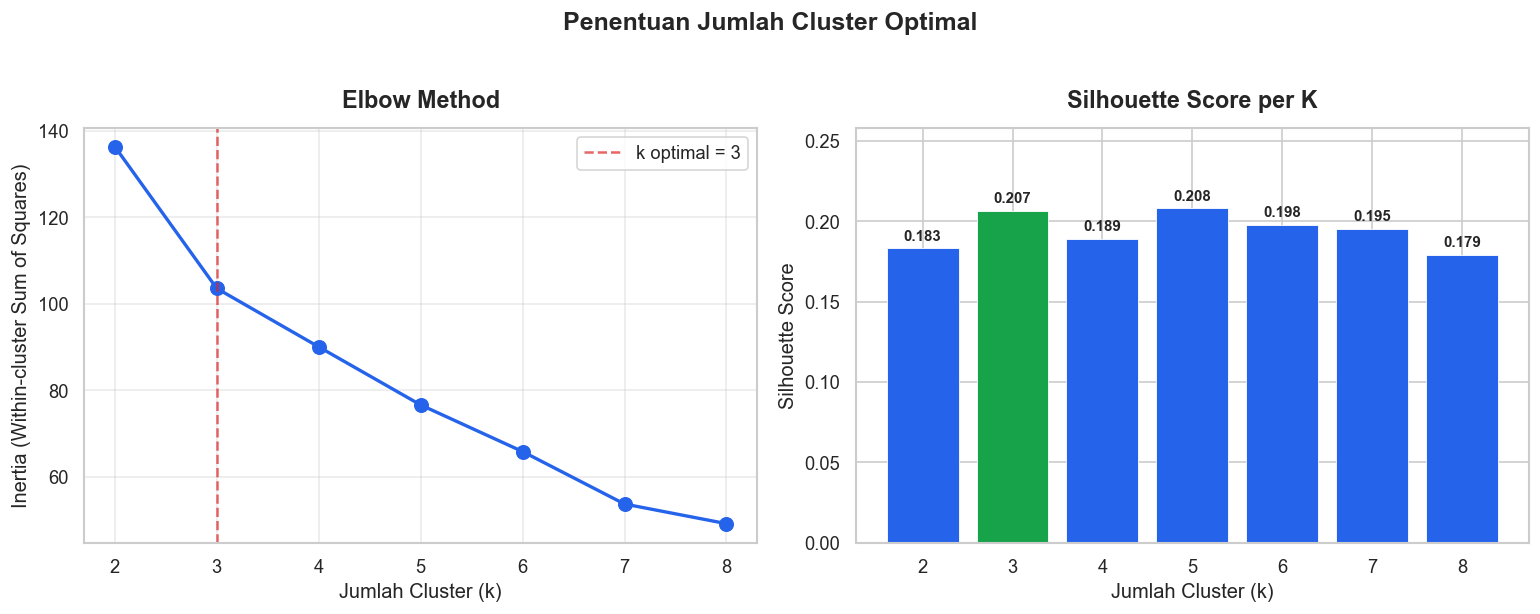


→ k=3 dipilih berdasarkan keseimbangan Elbow + Silhouette Score tertinggi


In [7]:
k_range = range(2, 9)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Elbow
axes[0].plot(k_range, inertias, 'o-', color='#2563EB', linewidth=2, markersize=8)
axes[0].axvline(x=3, color='#DC2626', linestyle='--', alpha=0.7, label='k optimal = 3')
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Jumlah Cluster (k)')
axes[0].set_ylabel('Inertia (Within-cluster Sum of Squares)')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

# Silhouette
bars = axes[1].bar(k_range, silhouettes, color=['#2563EB' if k != 3 else '#16A34A' for k in k_range],
                   edgecolor='white', linewidth=0.5)
axes[1].set_title('Silhouette Score per K', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Jumlah Cluster (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_ylim(0, max(silhouettes) + 0.05)

for bar, val in zip(bars, silhouettes):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Penentuan Jumlah Cluster Optimal', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_elbow_silhouette.png', bbox_inches='tight', dpi=150)
plt.show()
print('\n→ k=3 dipilih berdasarkan keseimbangan Elbow + Silhouette Score tertinggi')

## 6. Melatih Model K-Means (k=3)

In [8]:
OPTIMAL_K = 3

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
customer['Cluster'] = kmeans.fit_predict(X_scaled)

# Label nama cluster berdasarkan karakteristik
cluster_stats = customer.groupby('Cluster')[['total_spent', 'total_transactions', 'avg_spent']].mean()
rank = cluster_stats['total_spent'].rank().astype(int)

label_map = {}
for c, r in rank.items():
    if r == 3:
        label_map[c] = 'Premium'
    elif r == 2:
        label_map[c] = 'Reguler'
    else:
        label_map[c] = 'Hemat'

customer['Segment'] = customer['Cluster'].map(label_map)

print('Distribusi Pelanggan per Cluster:')
print(customer['Segment'].value_counts())
print(f'\nSilhouette Score final: {silhouette_score(X_scaled, customer["Cluster"]):.4f}')

Distribusi Pelanggan per Cluster:
Segment
Hemat      10
Reguler     9
Premium     6
Name: count, dtype: int64

Silhouette Score final: 0.2065


## 7. Analisis Karakteristik Cluster

In [9]:
summary = customer.groupby('Segment')[features].mean().round(2)
print('=== Rata-rata Fitur per Segmen Pelanggan ===')
summary

=== Rata-rata Fitur per Segmen Pelanggan ===


,total_transactions,total_spent,avg_spent,avg_quantity,discount_rate,avg_price_per_unit,online_ratio
Segment,,,,,,,
Hemat,500.40,63257.25,126.45,5.49,0.34,23.05,0.50
Premium,530.33,69683.17,131.42,5.55,0.34,23.60,0.51
Reguler,487.67,64789.89,132.90,5.61,0.33,23.57,0.51


In [10]:
print('=== Daftar Pelanggan per Segmen ===')
for seg in ['Premium', 'Reguler', 'Hemat']:
    cust_list = customer[customer['Segment'] == seg]['Customer ID'].tolist()
    print(f'\n{seg} ({len(cust_list)} pelanggan):')
    print(', '.join(cust_list))

=== Daftar Pelanggan per Segmen ===

Premium (6 pelanggan):
CUST_05, CUST_08, CUST_13, CUST_16, CUST_23, CUST_24

Reguler (9 pelanggan):
CUST_02, CUST_03, CUST_04, CUST_07, CUST_10, CUST_14, CUST_19, CUST_21, CUST_22

Hemat (10 pelanggan):
CUST_01, CUST_06, CUST_09, CUST_11, CUST_12, CUST_15, CUST_17, CUST_18, CUST_20, CUST_25


## 8. Visualisasi Cluster

### 8a. PCA — Sebaran Pelanggan dalam 2D

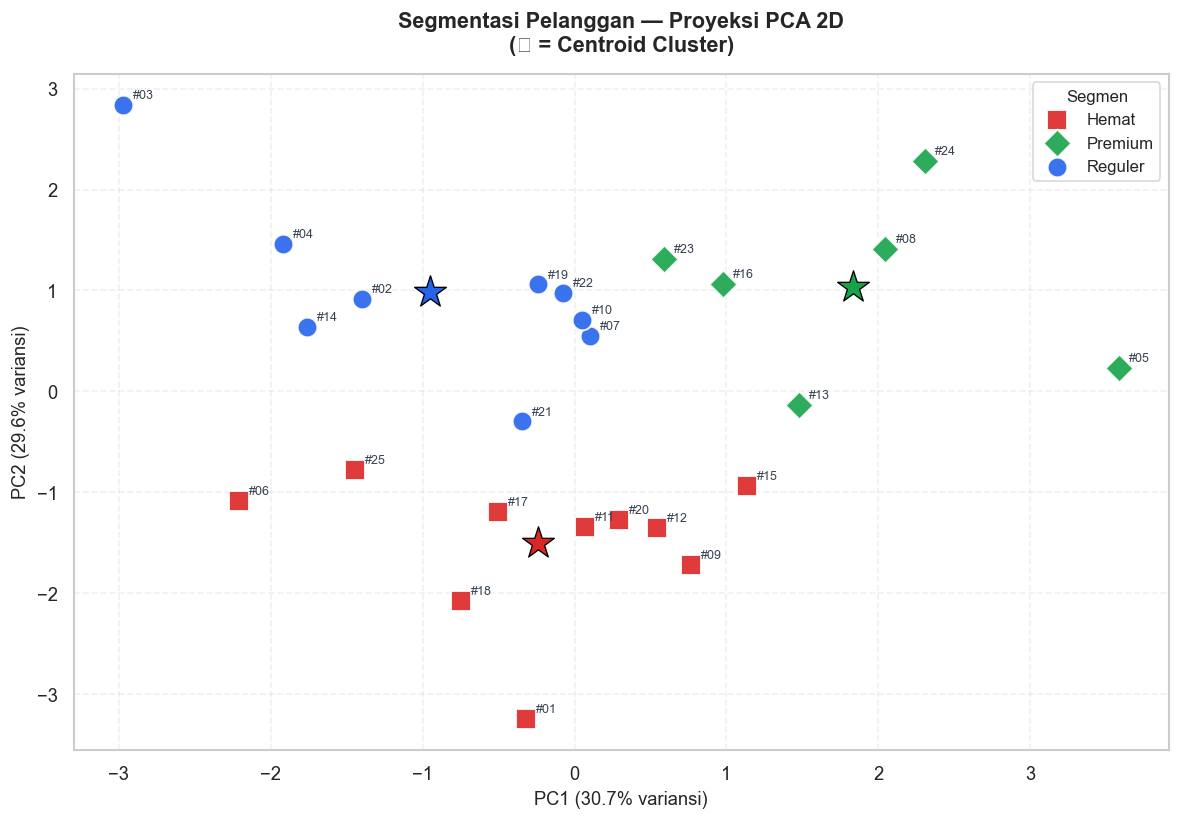

In [11]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

customer['PCA1'] = X_pca[:, 0]
customer['PCA2'] = X_pca[:, 1]

palette = {'Premium': '#16A34A', 'Reguler': '#2563EB', 'Hemat': '#DC2626'}
markers = {'Premium': 'D', 'Reguler': 'o', 'Hemat': 's'}

fig, ax = plt.subplots(figsize=(10, 7))

for seg, grp in customer.groupby('Segment'):
    ax.scatter(grp['PCA1'], grp['PCA2'],
               label=seg, c=palette[seg], marker=markers[seg],
               s=140, edgecolors='white', linewidths=1.2, alpha=0.9, zorder=3)
    for _, row in grp.iterrows():
        ax.annotate(row['Customer ID'].replace('CUST_', '#'),
                    (row['PCA1'], row['PCA2']),
                    textcoords='offset points', xytext=(6, 4),
                    fontsize=7.5, color='#374151')

# Centroid
centroids_pca = pca.transform(kmeans.cluster_centers_)
for i, (cx, cy) in enumerate(centroids_pca):
    seg = label_map[i]
    ax.scatter(cx, cy, c=palette[seg], marker='*', s=400,
               edgecolors='black', linewidths=0.8, zorder=5)

explained = pca.explained_variance_ratio_ * 100
ax.set_xlabel(f'PC1 ({explained[0]:.1f}% variansi)', fontsize=11)
ax.set_ylabel(f'PC2 ({explained[1]:.1f}% variansi)', fontsize=11)
ax.set_title('Segmentasi Pelanggan — Proyeksi PCA 2D\n(★ = Centroid Cluster)',
             fontsize=13, fontweight='bold', pad=14)
ax.legend(title='Segmen', fontsize=10, title_fontsize=10,
          framealpha=0.9, edgecolor='#D1D5DB')
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('plot_pca_cluster.png', bbox_inches='tight', dpi=150)
plt.show()

### 8b. Radar Chart — Profil Setiap Segmen

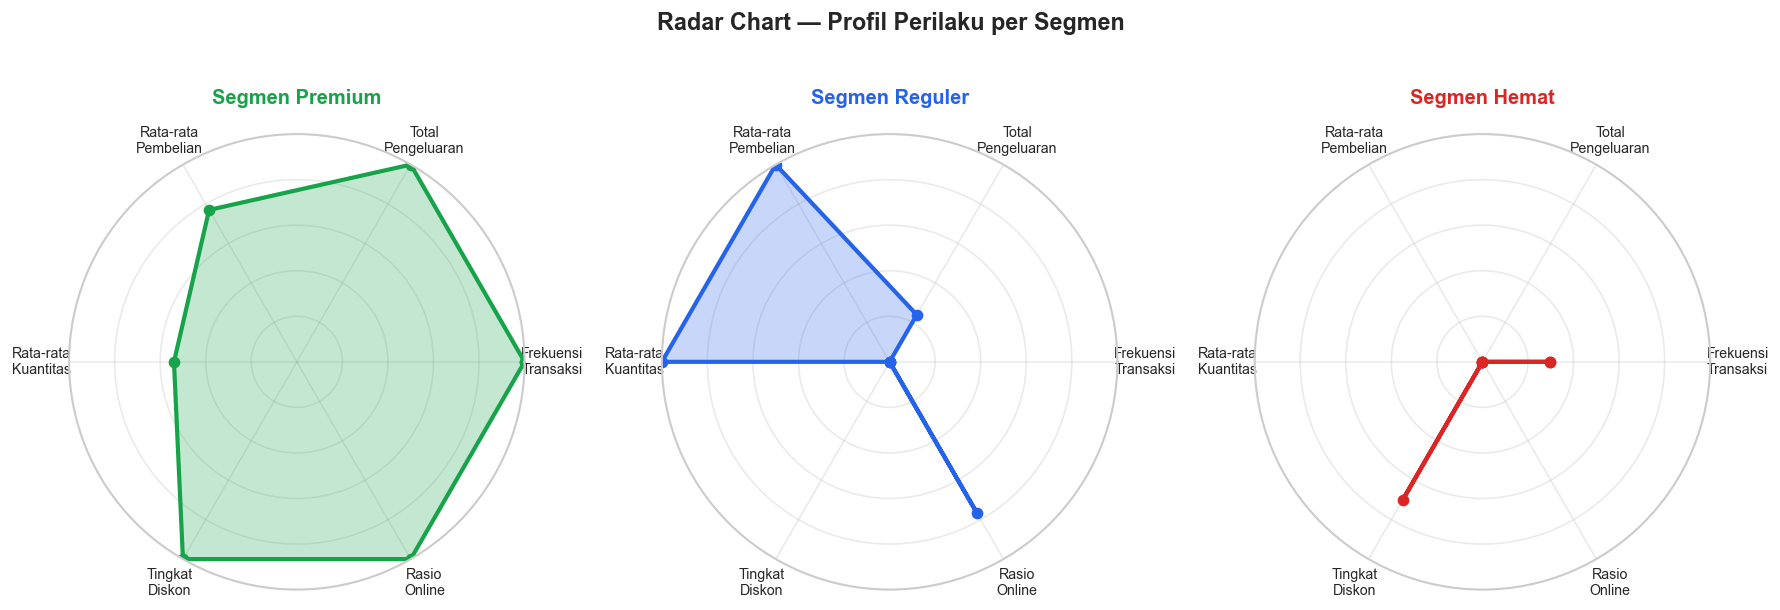

In [12]:
radar_features = ['total_transactions', 'total_spent', 'avg_spent',
                  'avg_quantity', 'discount_rate', 'online_ratio']
labels_radar = ['Frekuensi\nTransaksi', 'Total\nPengeluaran', 'Rata-rata\nPembelian',
                'Rata-rata\nKuantitas', 'Tingkat\nDiskon', 'Rasio\nOnline']

# Normalisasi 0–1 untuk radar
radar_data = customer.groupby('Segment')[radar_features].mean()
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min())

N = len(radar_features)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), subplot_kw={'polar': True})
segments_order = ['Premium', 'Reguler', 'Hemat']
colors = ['#16A34A', '#2563EB', '#DC2626']

for ax, seg, color in zip(axes, segments_order, colors):
    values = radar_norm.loc[seg].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2.5, color=color)
    ax.fill(angles, values, alpha=0.25, color=color)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels_radar, fontsize=8.5)
    ax.set_ylim(0, 1)
    ax.set_yticklabels([])
    ax.set_title(f'Segmen {seg}', size=12, fontweight='bold', pad=18, color=color)
    ax.grid(True, alpha=0.4)

plt.suptitle('Radar Chart — Profil Perilaku per Segmen', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('plot_radar.png', bbox_inches='tight', dpi=150)
plt.show()

### 8c. Bar Chart — Perbandingan Metrik Utama

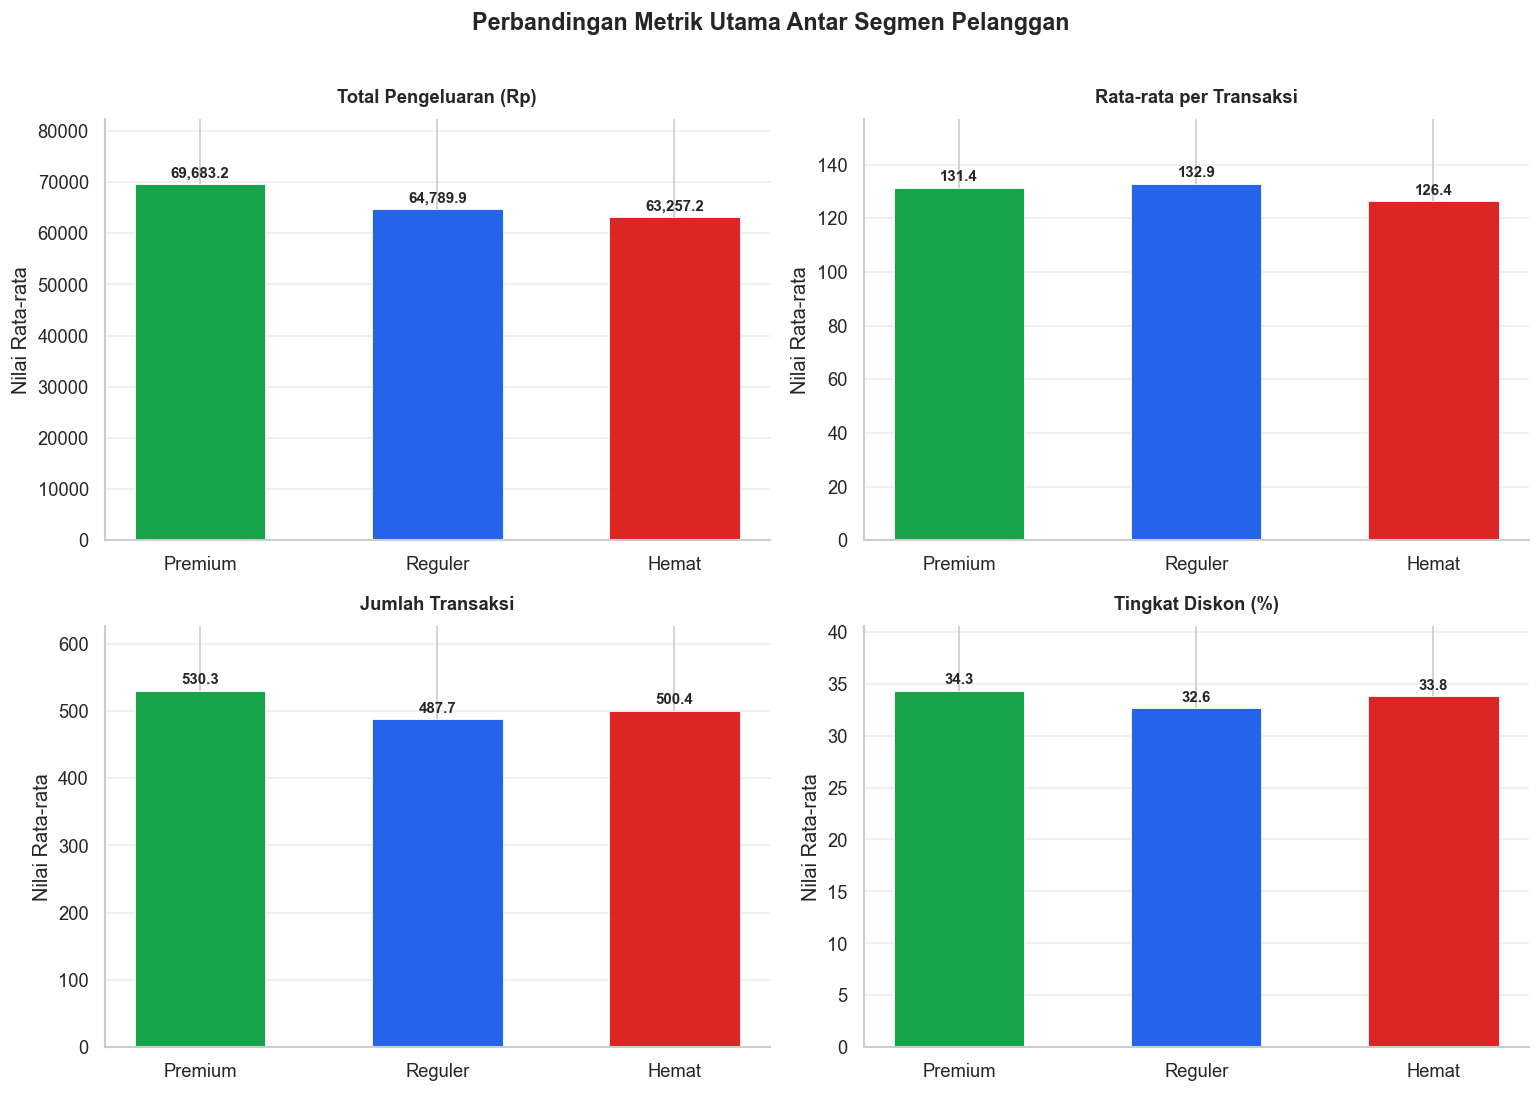

In [13]:
seg_order = ['Premium', 'Reguler', 'Hemat']
metrics = {
    'Total Pengeluaran (Rp)': 'total_spent',
    'Rata-rata per Transaksi': 'avg_spent',
    'Jumlah Transaksi': 'total_transactions',
    'Tingkat Diskon (%)': 'discount_rate'
}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()
colors_bar = ['#16A34A', '#2563EB', '#DC2626']

for ax, (title, col) in zip(axes, metrics.items()):
    vals = customer.groupby('Segment')[col].mean().reindex(seg_order)
    if col == 'discount_rate':
        vals = vals * 100

    bars = ax.bar(seg_order, vals, color=colors_bar, edgecolor='white',
                  linewidth=0.5, width=0.55)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                f'{val:,.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
    ax.set_ylabel('Nilai Rata-rata')
    ax.set_ylim(0, max(vals) * 1.18)
    ax.grid(axis='y', alpha=0.35)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Perbandingan Metrik Utama Antar Segmen Pelanggan',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_bar_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

### 8d. Heatmap Korelasi Fitur

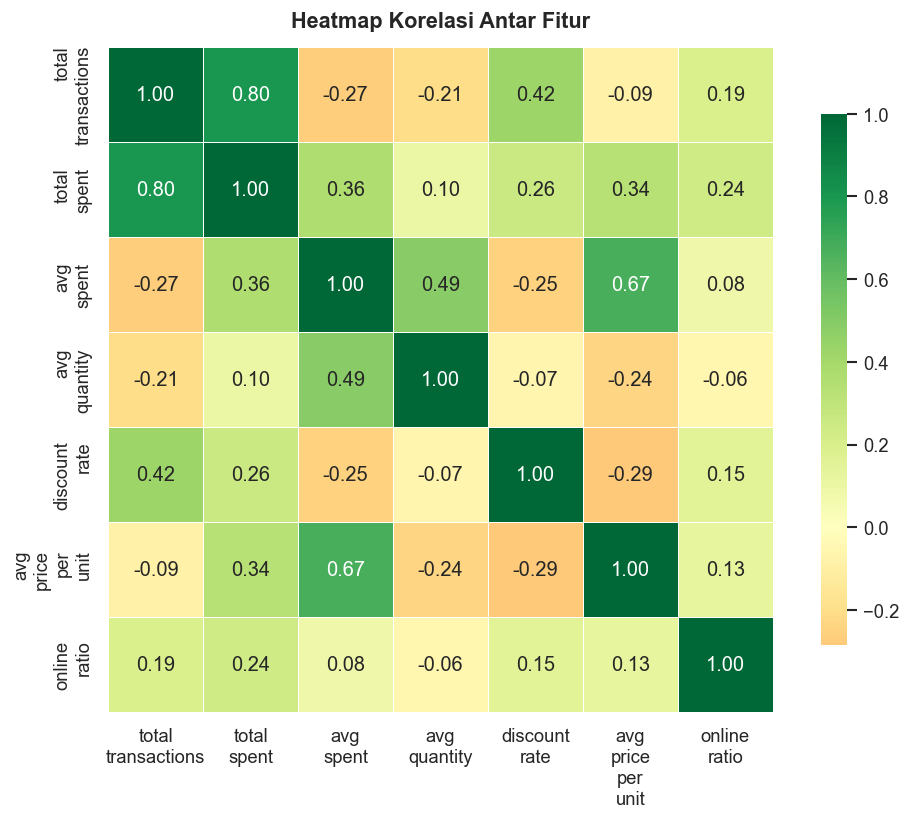

In [14]:
fig, ax = plt.subplots(figsize=(9, 7))
corr = customer[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax,
            xticklabels=[f.replace('_', '\n') for f in features],
            yticklabels=[f.replace('_', '\n') for f in features])

ax.set_title('Heatmap Korelasi Antar Fitur', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('plot_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

## 9. Ringkasan Hasil & Rekomendasi Strategi

In [15]:
print('=' * 65)
print('           RINGKASAN SEGMENTASI PELANGGAN')
print('=' * 65)

for seg in seg_order:
    grp = customer[customer['Segment'] == seg]
    n = len(grp)
    ts = grp['total_spent'].mean()
    txn = grp['total_transactions'].mean()
    avg = grp['avg_spent'].mean()
    dr = grp['discount_rate'].mean() * 100
    cust_ids = ', '.join(grp['Customer ID'].str.replace('CUST_', '#').tolist())

    print(f'\n📌 Segmen {seg.upper()} ({n} pelanggan)')
    print(f'   Pelanggan : {cust_ids}')
    print(f'   Total Pengeluaran rata-rata : Rp {ts:,.0f}')
    print(f'   Jumlah Transaksi rata-rata  : {txn:.0f} transaksi')
    print(f'   Nilai per Transaksi rata-rata: Rp {avg:,.0f}')
    print(f'   Tingkat Diskon digunakan    : {dr:.1f}%')

print('\n' + '=' * 65)
print('REKOMENDASI STRATEGI BISNIS')
print('=' * 65)
print('''
🟢 PREMIUM  → Loyalty program eksklusif, early access produk baru,
              penawaran bundling premium, personal shopping assistant.

🔵 REGULER  → Kampanye upselling, program reward poin, voucher
              diskon berkala untuk meningkatkan frekuensi pembelian.

🔴 HEMAT    → Flash sale, promo harga bundling, email marketing
              berbasis kebutuhan, program cicilan tanpa bunga.
''')
print('=' * 65)

           RINGKASAN SEGMENTASI PELANGGAN

📌 Segmen PREMIUM (6 pelanggan)
   Pelanggan : #05, #08, #13, #16, #23, #24
   Total Pengeluaran rata-rata : Rp 69,683
   Jumlah Transaksi rata-rata  : 530 transaksi
   Nilai per Transaksi rata-rata: Rp 131
   Tingkat Diskon digunakan    : 34.3%

📌 Segmen REGULER (9 pelanggan)
   Pelanggan : #02, #03, #04, #07, #10, #14, #19, #21, #22
   Total Pengeluaran rata-rata : Rp 64,790
   Jumlah Transaksi rata-rata  : 488 transaksi
   Nilai per Transaksi rata-rata: Rp 133
   Tingkat Diskon digunakan    : 32.6%

📌 Segmen HEMAT (10 pelanggan)
   Pelanggan : #01, #06, #09, #11, #12, #15, #17, #18, #20, #25
   Total Pengeluaran rata-rata : Rp 63,257
   Jumlah Transaksi rata-rata  : 500 transaksi
   Nilai per Transaksi rata-rata: Rp 126
   Tingkat Diskon digunakan    : 33.8%

REKOMENDASI STRATEGI BISNIS

🟢 PREMIUM  → Loyalty program eksklusif, early access produk baru,
              penawaran bundling premium, personal shopping assistant.

🔵 REGULER  → Kampa

In [16]:
# Ekspor hasil ke CSV
output = customer[['Customer ID', 'Cluster', 'Segment',
                    'total_transactions', 'total_spent', 'avg_spent',
                    'discount_rate', 'online_ratio']].round(4)
output.to_csv('hasil_segmentasi_pelanggan.csv', index=False)
print('✅ Hasil tersimpan: hasil_segmentasi_pelanggan.csv')

✅ Hasil tersimpan: hasil_segmentasi_pelanggan.csv
